In [3]:
import pandas as pd

df = pd.read_csv("../data/phishing_email.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 82486
Number of columns: 2


In [9]:
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [13]:
df.tail()

,text_combined,label
82481,info advantageapartmentscom infoadvantageapart...,1
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,1
82483,help center infohelpcentercoza_infohelpcenterc...,1
82484,metamask infosofamekarcom verify metamask wall...,1
82485,fastway infofastwaycoza_infofastwaycoza_infofa...,1


In [14]:
df.columns.tolist()

['text_combined', 'label']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [12]:
df.isnull().sum()

text_combined    0
label            0
dtype: int64

In [15]:
df["label"].value_counts()

label
1    42891
0    39595
Name: count, dtype: int64

In [16]:
df["label"].value_counts(normalize=True) * 100

label
1    51.997915
0    48.002085
Name: proportion, dtype: float64

In [17]:
df[df["label"] == 0]["text_combined"].head(5)

0    hpl nom may 25 2001 see attached file hplno 52...
1    nom actual vols 24 th forwarded sabrae zajac h...
2    enron actuals march 30 april 1 201 estimated a...
3    hpl nom may 30 2001 see attached file hplno 53...
4    hpl nom june 1 2001 see attached file hplno 60...
Name: text_combined, dtype: object

In [ ]:
df[df["label"] == 1]["text_combined"].head(5) #0 = Legitimate
                                              #1 = Phishing

3503    link dwl g 510 802 11 g wireless pci lan adapt...
3504    indemand payperview movies sports wed 15 sep 2...
3505    want lose 19 weight try adipren hello special ...
3506    cialis xanax valium viagra low price prescript...
3507    pre order see image click indelible backscatte...
Name: text_combined, dtype: object

In [19]:
df["text_combined"].duplicated().sum()

408

In [20]:
df.duplicated().sum()

408

In [21]:
df["text_length"] = df["text_combined"].str.len()

df["text_length"].describe()

count    8.248600e+04
mean     1.288751e+03
std      1.549675e+04
min      1.000000e+00
25%      2.760000e+02
50%      5.580000e+02
75%      1.338000e+03
max      4.279526e+06
Name: text_length, dtype: float64

In [23]:
df.groupby("text_combined")["label"].nunique().value_counts()

label
1    82078
Name: count, dtype: int64

In [24]:
df[df["text_combined"].duplicated(keep=False)].sort_values("text_combined").head(20)

,text_combined,label,text_length
1587,survive bid week hear lost another employee s...,0,249
1588,survive bid week hear lost another employee s...,0,249
8245,tani yes aware thanks letting know hr rep lon...,0,359
8244,tani yes aware thanks letting know hr rep lon...,0,359
2844,04 01 assignment termination expiration report...,0,370
2845,04 01 assignment termination expiration report...,0,370
8628,1 urgent outlook email notification new outloo...,0,1173
8627,1 urgent outlook email notification new outloo...,0,1173
8626,2 survey information email 5 7 01 current note...,0,957
8625,2 survey information email 5 7 01 current note...,0,957


In [25]:
df.groupby("label")["text_length"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
label,,,,,
0,39595,1536.096098,779.0,11,160318
1,42891,1060.413793,391.0,1,4279526


In [26]:
df = df.drop_duplicates(subset="text_combined").reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (82078, 3)


In [28]:
df = df.drop(columns=["text_length"])

print(df.shape)
print(df.columns.tolist())

(82078, 2)
['text_combined', 'label']


In [29]:
df["text_combined"].str.strip().eq("").sum()

1

In [30]:
df = df[df["text_combined"].str.strip() != ""].reset_index(drop=True)

print("New dataset shape:", df.shape)

New dataset shape: (82077, 2)


In [31]:
df["label"].value_counts()

label
1    42844
0    39233
Name: count, dtype: int64

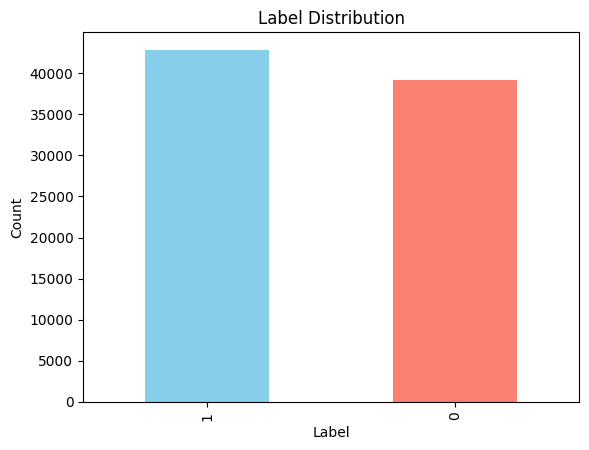

In [32]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


In [34]:
df["text_combined"] = df["text_combined"].str.lower()

df[["text_combined", "label"]].head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [35]:
import re

df["text_combined"] = df["text_combined"].apply(
    lambda x: re.sub(r"[^a-zA-Z0-9\s]", "", x)
)

df[["text_combined", "label"]].head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [36]:
df["text_combined"] = df["text_combined"].str.replace(r"\s+", " ", regex=True).str.strip()

df[["text_combined", "label"]].head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [38]:
pip install nltk

  Using cached nltk-3.10.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached regex-2026.7.19-cp310-cp310-win_amd64.whl.metadata (41 kB)
Using cached nltk-3.10.2-py3-none-any.whl (1.7 MB)
Using cached regex-2026.7.19-cp310-cp310-win_amd64.whl (277 kB)
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)

   ---------------------------------------- 0/3 [regex]
   ------------- -------------------------- 1/3 [defusedxml]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   ----


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

df["text_combined"] = df["text_combined"].apply(
    lambda x: " ".join(word for word in x.split() if word not in stop_words)
)

df[["text_combined", "label"]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\grees\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [40]:
df[["text_combined", "label"]].head(10)

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0
5,hpl nom may 31 2001 see attached file hplno 53...,0
6,9760 tried get fancy address came back forward...,0
7,hpl noms february 15 2000 see attached file hp...,0
8,fw pooling contract template original message ...,0
9,hpl nom march 28 2000 see attached file hplo 3...,0


In [41]:
df.shape

(82077, 2)

In [42]:
df.to_csv("../data/cleaned_phishing_email.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [43]:
from sklearn.model_selection import train_test_split

X = df["text_combined"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 65661
Testing samples: 16416


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (65661, 10000)
Testing TF-IDF shape: (16416, 10000)


In [45]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [46]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = lr_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9825170565302144

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7847
           1       0.98      0.99      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



In [47]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

print("Linear SVM training completed!")

Linear SVM training completed!


In [48]:
from sklearn.metrics import accuracy_score, classification_report

svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9875121832358674

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      7847
           1       0.99      0.99      0.99      8569

    accuracy                           0.99     16416
   macro avg       0.99      0.99      0.99     16416
weighted avg       0.99      0.99      0.99     16416



In [49]:
import joblib

joblib.dump(svm_model, "../models/svm_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


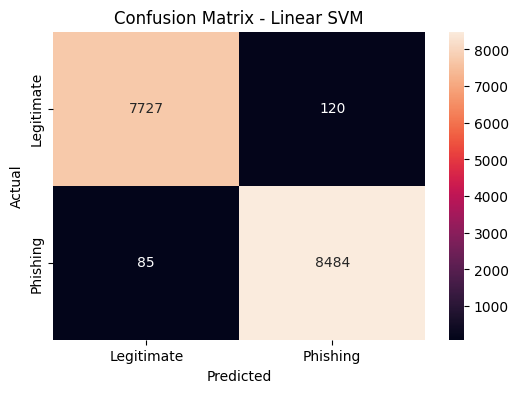

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [51]:
from sklearn.metrics import roc_auc_score

svm_scores = svm_model.decision_function(X_test_tfidf)

roc_auc = roc_auc_score(y_test, svm_scores)

print("SVM ROC-AUC Score:", roc_auc)

SVM ROC-AUC Score: 0.9989216763363952
